In [1]:
import os
os.environ['DYLD_LIBRARY_PATH'] = '/opt/homebrew/opt/libomp/lib'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [2]:
df = pd.read_csv(
    'SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'message'],
    encoding='utf-8'
)
 
print(f"✅ 데이터 로드 완료: {df.shape}")
print(df.head())

✅ 데이터 로드 완료: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


=== 레이블 분포 ===
label
ham     4825
spam     747
Name: count, dtype: int64

스팸 비율: 13.4%


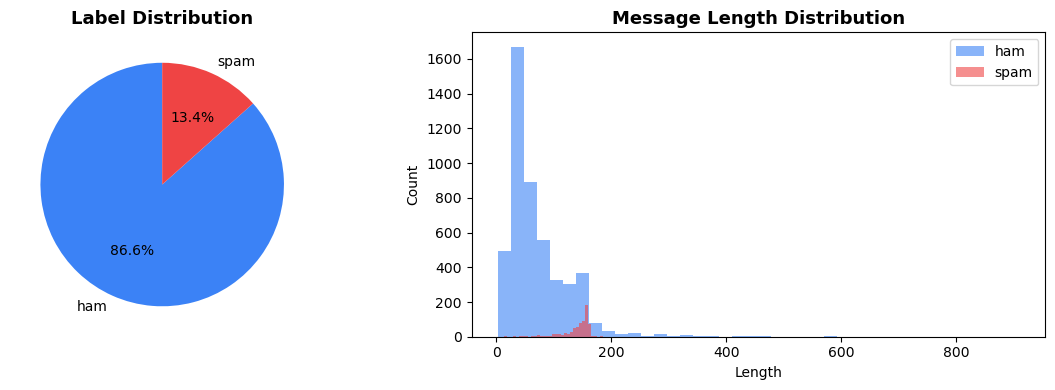

✅ EDA 완료


In [3]:
print("=== 레이블 분포 ===")
print(df['label'].value_counts())
print(f"\n스팸 비율: {df['label'].value_counts(normalize=True)['spam']:.1%}")

df['msg_len'] = df['message'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['label'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%',
    colors=['#3b82f6', '#ef4444'], startangle=90
)
axes[0].set_title('Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('')

for label, color in [('ham', '#3b82f6'), ('spam', '#ef4444')]:
    subset = df[df['label'] == label]['msg_len']
    axes[1].hist(subset, bins=40, alpha=0.6, label=label, color=color)
axes[1].set_title('Message Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA 완료")

In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_msg'] = df['message'].apply(clean_text)
df['label_num'] = (df['label'] == 'spam').astype(int)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X = tfidf.fit_transform(df['clean_msg'])
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ 전처리 완료")
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

✅ 전처리 완료
Train: (4457, 3000), Test: (1115, 3000)


In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'auc':      roc_auc_score(y_test, y_prob),
        'y_prob':   y_prob
    }
    print(f"\n{'='*40}")
    print(f"📌 {name}")
    print(f"Accuracy : {results[name]['accuracy']:.4f}")
    print(f"AUC      : {results[name]['auc']:.4f}")
    print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

print("\n✅ 모델 학습 완료")


📌 Logistic Regression
Accuracy : 0.9713
AUC      : 0.9878
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115


📌 Random Forest
Accuracy : 0.9749
AUC      : 0.9888
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       1.00      0.81      0.90       149

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115


📌 XGBoost
Accuracy : 0.9722
AUC      : 0.9814
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98       966
        spam       0.95      0.83      0.89       149

    accuracy           

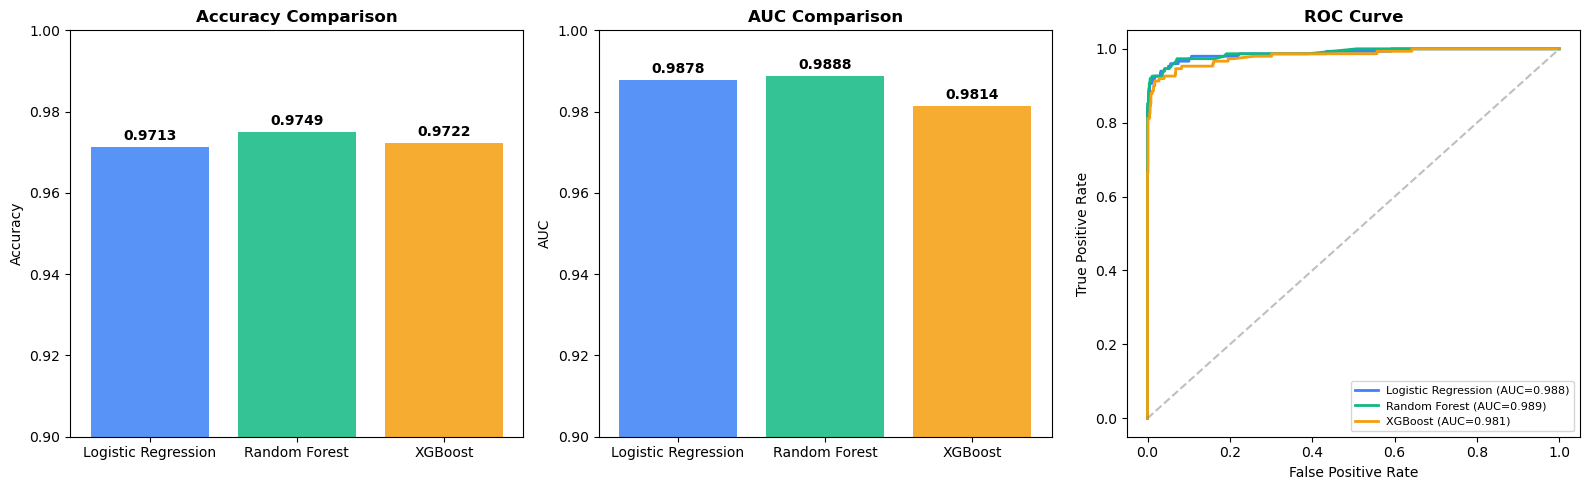

✅ 성능 비교 시각화 완료


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
aucs        = [results[m]['auc']      for m in model_names]
colors      = ['#3b82f6', '#10b981', '#f59e0b']

bars = axes[0].bar(model_names, accuracies, color=colors, alpha=0.85)
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylim(0.9, 1.0)
axes[0].set_ylabel('Accuracy')
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(model_names, aucs, color=colors, alpha=0.85)
axes[1].set_title('AUC Comparison', fontweight='bold')
axes[1].set_ylim(0.9, 1.0)
axes[1].set_ylabel('AUC')
for bar, val in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

for name, color in zip(model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    axes[2].plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.3f})", color=color, lw=2)
axes[2].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[2].set_title('ROC Curve', fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 성능 비교 시각화 완료")

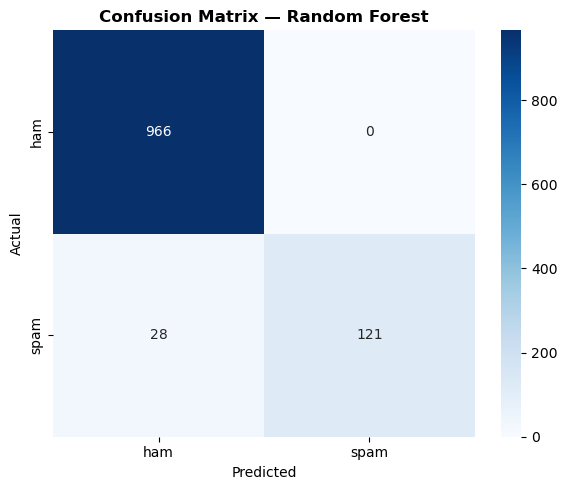


✅ Best Model: Random Forest
   Accuracy : 0.9749
   AUC      : 0.9888


In [7]:
best_name = max(results, key=lambda m: results[m]['auc'])
best_pred = results[best_name]['y_pred']

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'])
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Best Model: {best_name}")
print(f"   Accuracy : {results[best_name]['accuracy']:.4f}")
print(f"   AUC      : {results[best_name]['auc']:.4f}")

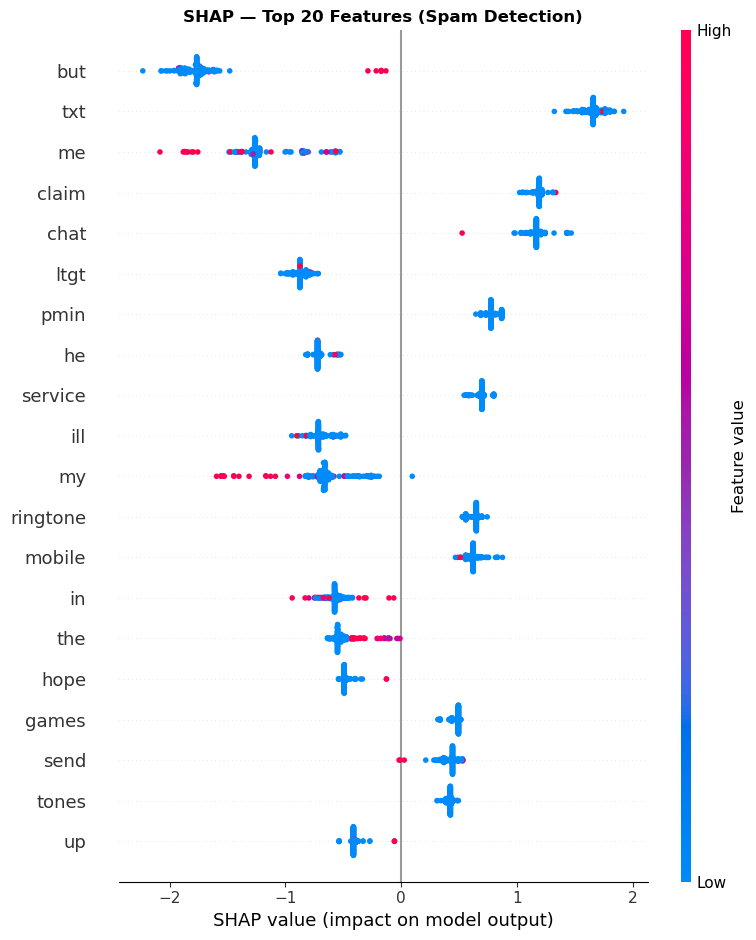

✅ SHAP 분석 완료


In [8]:
xgb_model  = results['XGBoost']['model']
X_test_arr = X_test.toarray()

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_arr[:200])

feature_names = tfidf.get_feature_names_out()

plt.figure()
shap.summary_plot(
    shap_values, X_test_arr[:200],
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP — Top 20 Features (Spam Detection)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP 분석 완료")

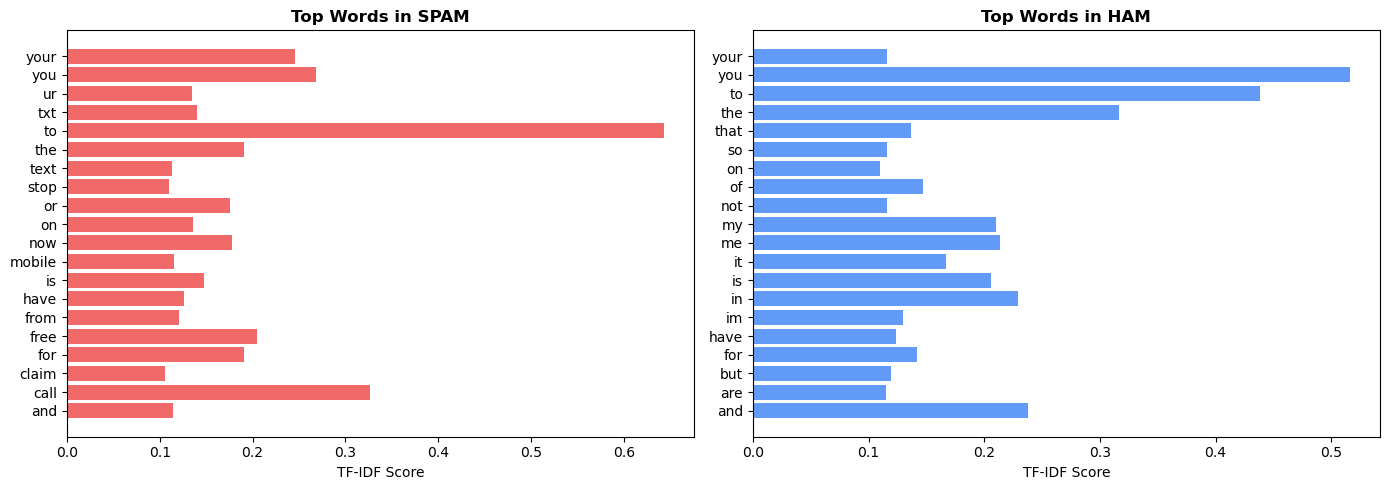

✅ 단어 분석 완료

📊 최종 모델 성능 요약
              Model Accuracy    AUC
Logistic Regression   0.9713 0.9878
      Random Forest   0.9749 0.9888
            XGBoost   0.9722 0.9814

🏆 Best Model: Random Forest


In [9]:
# Cell 10
spam_msgs = ' '.join(df[df['label']=='spam']['clean_msg'])
ham_msgs  = ' '.join(df[df['label']=='ham']['clean_msg'])

spam_tfidf = TfidfVectorizer(max_features=20, ngram_range=(1,1))
ham_tfidf  = TfidfVectorizer(max_features=20, ngram_range=(1,1))

spam_tfidf.fit([spam_msgs])
ham_tfidf.fit([ham_msgs])

spam_words = spam_tfidf.get_feature_names_out()
ham_words  = ham_tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

spam_scores = spam_tfidf.transform([spam_msgs]).toarray()[0]
axes[0].barh(spam_words, spam_scores, color='#ef4444', alpha=0.8)
axes[0].set_title('Top Words in SPAM', fontweight='bold')
axes[0].set_xlabel('TF-IDF Score')

ham_scores = ham_tfidf.transform([ham_msgs]).toarray()[0]
axes[1].barh(ham_words, ham_scores, color='#3b82f6', alpha=0.8)
axes[1].set_title('Top Words in HAM', fontweight='bold')
axes[1].set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 단어 분석 완료")

# Cell 11
print("\n" + "="*50)
print("📊 최종 모델 성능 요약")
print("="*50)
summary = pd.DataFrame({
    'Model':    model_names,
    'Accuracy': [f"{results[m]['accuracy']:.4f}" for m in model_names],
    'AUC':      [f"{results[m]['auc']:.4f}"      for m in model_names]
})
print(summary.to_string(index=False))
print(f"\n🏆 Best Model: {best_name}")
print("="*50)